In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from scipy.sparse import csr_matrix
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('movies_metadata.csv', low_memory=False)
print('Shape:', df.shape)
print('\nColumn Names:')
print(df.columns.tolist())
print('\nFirst 3 rows:')
df.head(3)

Shape: (45466, 24)

Column Names:
['adult', 'belongs_to_collection', 'budget', 'genres', 'homepage', 'id', 'imdb_id', 'original_language', 'original_title', 'overview', 'popularity', 'poster_path', 'production_companies', 'production_countries', 'release_date', 'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title', 'video', 'vote_average', 'vote_count']

First 3 rows:


,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0


In [3]:
# Keep only useful columns (adjust names based on Cell 2 output)
cols_needed = ['id', 'title', 'genres', 'vote_average', 'vote_count', 'popularity']
df = df[cols_needed]

# Drop missing values
df.dropna(inplace=True)
df.drop_duplicates(subset='title', inplace=True)

# Convert types
df['vote_average'] = pd.to_numeric(df['vote_average'], errors='coerce')
df['vote_count']   = pd.to_numeric(df['vote_count'],   errors='coerce')
df['popularity']   = pd.to_numeric(df['popularity'],   errors='coerce')
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

print('Cleaned shape:', df.shape)
df.head()

Cleaned shape: (42277, 6)


,id,title,genres,vote_average,vote_count,popularity
0,862,Toy Story,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",7.7,5415.0,21.946943
1,8844,Jumanji,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",6.9,2413.0,17.015539
2,15602,Grumpier Old Men,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",6.5,92.0,11.712900
3,31357,Waiting to Exhale,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",6.1,34.0,3.859495
4,11862,Father of the Bride Part II,"[{'id': 35, 'name': 'Comedy'}]",5.7,173.0,8.387519


In [4]:
# Label movies as High-rated (1) or Low-rated (0) based on vote_average
threshold = df['vote_average'].median()
df['rating_label'] = (df['vote_average'] >= threshold).astype(int)

print(f'Threshold (median vote): {threshold}')
print('\nLabel Distribution:')
print(df['rating_label'].value_counts())

Threshold (median vote): 6.0

Label Distribution:
rating_label
1    22690
0    19587
Name: count, dtype: int64


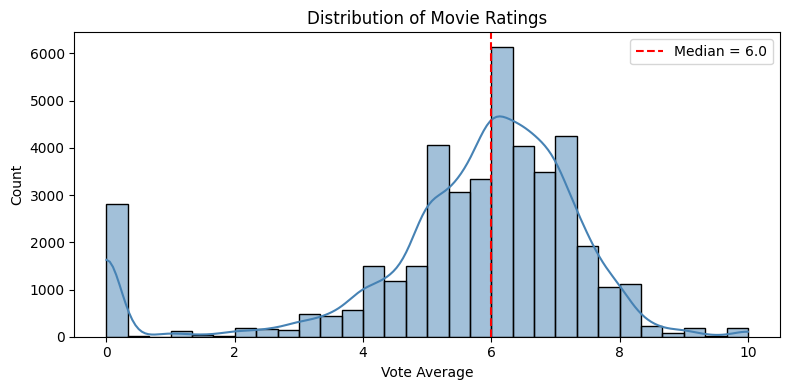

In [5]:
plt.figure(figsize=(8, 4))
sns.histplot(df['vote_average'], bins=30, kde=True, color='steelblue')
plt.axvline(threshold, color='red', linestyle='--', label=f'Median = {threshold}')
plt.title('Distribution of Movie Ratings')
plt.xlabel('Vote Average')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

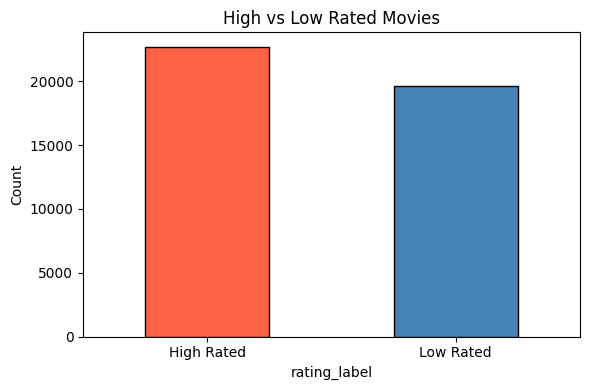

In [6]:
plt.figure(figsize=(6, 4))
df['rating_label'].value_counts().plot(
    kind='bar', color=['tomato', 'steelblue'], edgecolor='black'
)
plt.xticks([0, 1], ['High Rated', 'Low Rated'], rotation=0)
plt.title('High vs Low Rated Movies')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

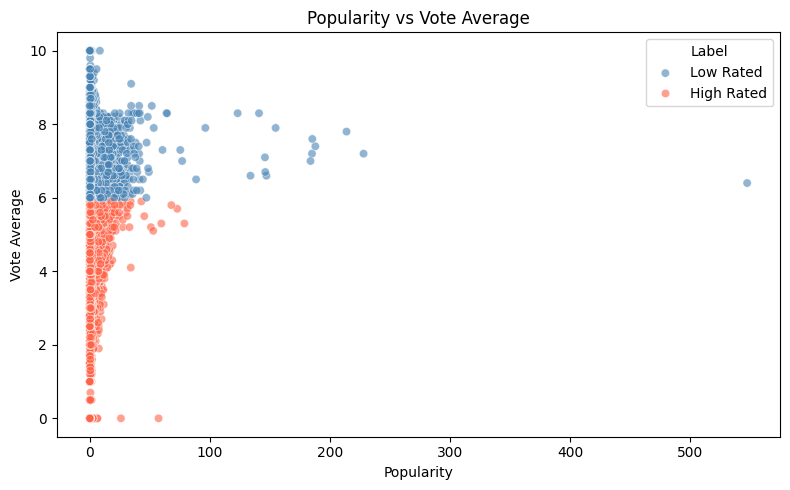

In [7]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df, x='popularity', y='vote_average',
    hue='rating_label', palette={0: 'tomato', 1: 'steelblue'},
    alpha=0.6
)
plt.title('Popularity vs Vote Average')
plt.xlabel('Popularity')
plt.ylabel('Vote Average')
plt.legend(title='Label', labels=['Low Rated', 'High Rated'])
plt.tight_layout()
plt.show()

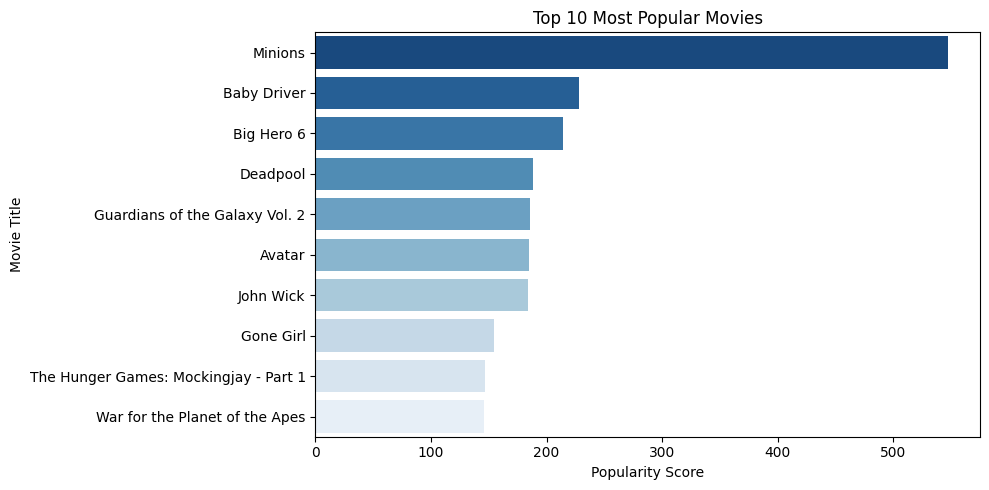

In [8]:
top10 = df.nlargest(10, 'popularity')[['title', 'popularity', 'vote_average']]

plt.figure(figsize=(10, 5))
sns.barplot(data=top10, x='popularity', y='title', palette='Blues_r')
plt.title('Top 10 Most Popular Movies')
plt.xlabel('Popularity Score')
plt.ylabel('Movie Title')
plt.tight_layout()
plt.show()

In [9]:
# Features for KNN
features = df[['vote_average', 'vote_count', 'popularity']].copy()

# Normalize features to 0-1 range
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
features_scaled = scaler.fit_transform(features)

print('Feature matrix shape:', features_scaled.shape)

Feature matrix shape: (42277, 3)


In [10]:
X = features_scaled
y = df['rating_label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Training samples:', X_train.shape[0])
print('Testing  samples:', X_test.shape[0])

Training samples: 33821
Testing  samples: 8456


In [11]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5, metric='cosine')
knn.fit(X_train, y_train)
print('KNN Model trained successfully!')

KNN Model trained successfully!


In [12]:
y_pred = knn.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f'Accuracy: {acc * 100:.2f}%\n')
print(classification_report(y_test, y_pred, target_names=['Low Rated', 'High Rated']))

Accuracy: 64.08%

              precision    recall  f1-score   support

   Low Rated       0.62      0.59      0.60      3918
  High Rated       0.66      0.68      0.67      4538

    accuracy                           0.64      8456
   macro avg       0.64      0.64      0.64      8456
weighted avg       0.64      0.64      0.64      8456



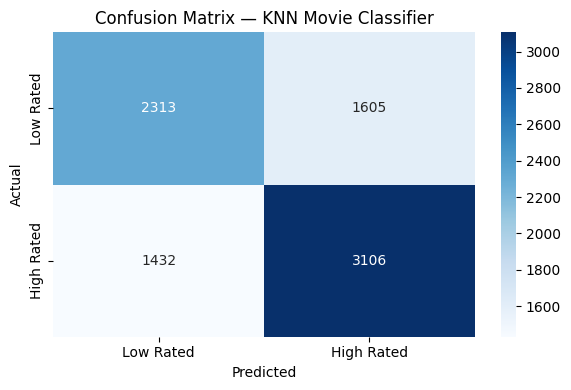

In [13]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Low Rated', 'High Rated'],
    yticklabels=['Low Rated', 'High Rated']
)
plt.title('Confusion Matrix — KNN Movie Classifier')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [14]:
def recommend_movies(movie_title, n=5):
    # Find movie index
    matches = df[df['title'].str.lower() == movie_title.lower()]
    if matches.empty:
        print(f'Movie "{movie_title}" not found in dataset.')
        return

    idx = matches.index[0]
    movie_features = features_scaled[idx].reshape(1, -1)

    # Find nearest neighbours
    nbrs = NearestNeighbors(n_neighbors=n+1, metric='cosine')
    nbrs.fit(features_scaled)
    distances, indices = nbrs.kneighbors(movie_features)

    print(f'\nTop {n} movies similar to "{movie_title}":\n')
    print(f'{"#":<4} {"Title":<45} {"Rating":>8} {"Popularity":>12}')
    print('-' * 72)
    for rank, i in enumerate(indices[0][1:], 1):
        print(f'{rank:<4} {df.loc[i, "title"]:<45} {df.loc[i, "vote_average"]:>8.1f} {df.loc[i, "popularity"]:>12.1f}')

In [15]:
# Test the recommender — replace with any movie title from your dataset
recommend_movies('The Dark Knight')

# ── Summary ──
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
print('\n' + '='*40)
print('         MODEL SUMMARY')
print('='*40)
print(f'  Accuracy              : {accuracy_score(y_test, y_pred)*100:.2f}%')
print(f'  High Rated Recall     : {tp/(tp+fn)*100:.2f}%')
print(f'  Low Rated Recall      : {tn/(tn+fp)*100:.2f}%')
print(f'  True Positives        : {tp}')
print(f'  True Negatives        : {tn}')
print(f'  False Positives       : {fp}')
print(f'  False Negatives       : {fn}')
print('='*40)


Top 5 movies similar to "The Dark Knight":

#    Title                                           Rating   Popularity
------------------------------------------------------------------------
1    Suicide Squad                                      5.9         43.0
2    Deadpool                                           7.4        187.9
3    Guardians of the Galaxy                            7.9         53.3
4    Avatar                                             7.2        185.1
5    Jurassic World                                     6.5         32.8

         MODEL SUMMARY
  Accuracy              : 64.08%
  High Rated Recall     : 68.44%
  Low Rated Recall      : 59.04%
  True Positives        : 3106
  True Negatives        : 2313
  False Positives       : 1605
  False Negatives       : 1432
